In [1]:
import os
import pandas as pd

In [2]:
list_of_reports = [k for k in os.listdir() if "VLLM_TEST" in k and ".xlsx" in k]
list_of_adapter_names = [k.replace(".xlsx", "") for k in list_of_reports if "VLLM_TEST" in k and ".xlsx" in k]

In [3]:
dfs_list = []
for i in range(len(list_of_reports)):
    
    df = pd.read_excel(list_of_reports[i])
    df["Adapter name"] = list_of_adapter_names[i]
    adapter_type = ""
    if "adapter" in list_of_adapter_names[i]:
        adapter_type = "LoRa"
    if "RAG" in list_of_adapter_names[i]:
        adapter_type = "RAG"
    if "clear" in list_of_adapter_names[i] and "full_finetune" not in list_of_adapter_names[i]:
        adapter_type = "Clear"   
    if "clear" in list_of_adapter_names[i] and "full_finetune" in list_of_adapter_names[i]:
        adapter_type = "Full fine tune"  

    df["Type"] = adapter_type
    dfs_list.append(df)

dfs_all = pd.concat(dfs_list, ignore_index = True)




    

    

In [4]:
dfs_all["Type"].value_counts()

Type
LoRa              3885
RAG                315
Clear              315
Full fine tune     210
Name: count, dtype: int64

In [5]:
dfs_all.to_excel("All_data_VLLM.xlsx", index = False)

In [6]:
dfs_all.columns

Index(['Promts', 'References', 'Answers', 'Response times',
       'Completion tokens', 'Tokens per second', 'Exact Match', 'BLEU',
       'ROUGE-L', 'METEOR', 'BERTScore F1', 'Adapter name', 'Type'],
      dtype='object')

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Настройки графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
%matplotlib inline


In [8]:
# Основные метрики качества и производительности
quality_metrics = ['Exact Match', 'BLEU', 'ROUGE-L', 'METEOR', 'BERTScore F1']
performance_metrics = ['Response times', 'Completion tokens', 'Tokens per second']

# Группировка по типу
stats_by_type = dfs_all.groupby('Type')[quality_metrics + performance_metrics].describe()
display(stats_by_type)


Exact Match                                               \
                     count      mean       std  min  25%  50%  75%  max   
Type                                                                      
Clear                315.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.0   
Full fine tune       210.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.0   
LoRa                3885.0  0.444273  0.496949  0.0  0.0  0.0  1.0  1.0   
RAG                  315.0  0.257143  0.437754  0.0  0.0  0.0  1.0  1.0   

                  BLEU            ... Completion tokens          \
                 count      mean  ...               75%     max   
Type                              ...                             
Clear            315.0  0.002635  ...             513.5  1600.0   
Full fine tune   210.0  0.193032  ...            1600.0  1600.0   
LoRa            3885.0  0.706523  ...             808.0  1600.0   
RAG              315.0  0.540094  ...            1600.0  1600.0   

               Tokens per second                                             \
                           count       mean       std        min        25%   
Type                                                                          
Clear                      315.0  95.326758  2.477113  53.402939  95.415320   
Full fine tune             210.0  95.435384  0.283641  91.910373  95.405781   
LoRa                      3885.0  93.547717  2.401132  86.769857  90.680794   
RAG                        315.0  92.254897  3.918898  69.236190  92.776223   

                                                 
                      50%        75%        max  
Type                                             
Clear           95.737699  95.863618  96.741765  
Full fine tune  95.444451  95.490700  96.628670  
LoRa            95.402016  95.630079  97.143146  
RAG             93.632621  93.995884  95.430288  

[4 rows x 64 columns]

In [9]:
percentiles = [0.1, 0.25, 0.5, 0.75, 0.9]
for metric in quality_metrics + performance_metrics:
    print(f"\nПроцентили для {metric}:")
    perc_df = dfs_all.groupby('Type')[metric].quantile(percentiles).unstack()
    display(perc_df)
    


Процентили для Exact Match:


,0.10,0.25,0.50,0.75,0.90
Type,,,,,
Clear,0.0,0.0,0.0,0.0,0.0
Full fine tune,0.0,0.0,0.0,0.0,0.0
LoRa,0.0,0.0,0.0,1.0,1.0
RAG,0.0,0.0,0.0,1.0,1.0



Процентили для BLEU:


,0.10,0.25,0.50,0.75,0.90
Type,,,,,
Clear,0.000000,0.000002,0.001066,0.003627,0.007469
Full fine tune,0.004325,0.016197,0.070832,0.282130,0.610520
LoRa,0.029425,0.356990,0.926409,1.000000,1.000000
RAG,0.000025,0.112697,0.482461,1.000000,1.000000



Процентили для ROUGE-L:


...

,0.10,0.25,0.50,0.75,0.90
Type,,,,,
Clear,0.266225,1.176450,3.720567,5.357145,16.670975
Full fine tune,16.739918,16.755427,16.763555,16.770273,16.775185
LoRa,2.660937,3.864158,6.553735,8.665933,12.086328
RAG,0.681570,2.003093,7.153685,16.970626,17.070024



Процентили для Completion tokens:


,0.10,0.25,0.50,0.75,0.90
Type,,,,,
Clear,25.0,112.5,356.0,513.5,1600.0
Full fine tune,1600.0,1600.0,1600.0,1600.0,1600.0
LoRa,247.0,358.0,598.0,808.0,1128.6
RAG,59.8,189.5,666.0,1600.0,1600.0



Процентили для Tokens per second:


,0.10,0.25,0.50,0.75,0.90
Type,,,,,
Clear,94.272651,95.415320,95.737699,95.863618,95.976959
Full fine tune,95.374734,95.405781,95.444451,95.490700,95.544899
LoRa,90.518585,90.680794,95.402016,95.630079,95.750820
RAG,88.922518,92.776223,93.632621,93.995884,94.298922


In [10]:
def mean_ci(data, confidence=0.95):
    n = len(data)
    mean = np.mean(data)
    se = stats.sem(data)  # стандартная ошибка среднего
    h = se * stats.t.ppf((1 + confidence) / 2., n-1)
    return mean - h, mean + h

ci_results = {}
for metric in quality_metrics + performance_metrics:
    ci_results[metric] = {}
    for t in dfs_all['Type'].unique():
        values = dfs_all[dfs_all['Type'] == t][metric].dropna()
        if len(values) > 1:
            low, high = mean_ci(values)
            ci_results[metric][t] = (low, high)
            print(f"{metric} | {t}: 95% ДИ = [{low:.4f}, {high:.4f}]")

Exact Match | LoRa: 95% ДИ = [0.4286, 0.4599]
Exact Match | RAG: 95% ДИ = [0.2086, 0.3057]
Exact Match | Clear: 95% ДИ = [0.0000, 0.0000]
Exact Match | Full fine tune: 95% ДИ = [0.0000, 0.0000]
BLEU | LoRa: 95% ДИ = [0.6944, 0.7187]
BLEU | RAG: 95% ДИ = [0.4941, 0.5861]
BLEU | Clear: 95% ДИ = [0.0022, 0.0031]
BLEU | Full fine tune: 95% ДИ = [0.1610, 0.2250]
ROUGE-L | LoRa: 95% ДИ = [0.8417, 0.8568]
ROUGE-L | RAG: 95% ДИ = [0.5562, 0.6438]
ROUGE-L | Clear: 95% ДИ = [0.2891, 0.3252]
ROUGE-L | Full fine tune: 95% ДИ = [0.4623, 0.5252]
METEOR | LoRa: 95% ДИ = [0.7508, 0.7712]
METEOR | RAG: 95% ДИ = [0.6401, 0.7270]
METEOR | Clear: 95% ДИ = [0.0379, 0.0452]
METEOR | Full fine tune: 95% ДИ = [0.3919, 0.4689]
BERTScore F1 | LoRa: 95% ДИ = [0.9245, 0.9313]
BERTScore F1 | RAG: 95% ДИ = [0.8428, 0.8768]
BERTScore F1 | Clear: 95% ДИ = [0.6235, 0.6364]
BERTScore F1 | Full fine tune: 95% ДИ = [0.8052, 0.8335]
Response times | LoRa: 95% ДИ = [6.8729, 7.1142]
Response times | RAG: 95% ДИ = [8.0760, 9

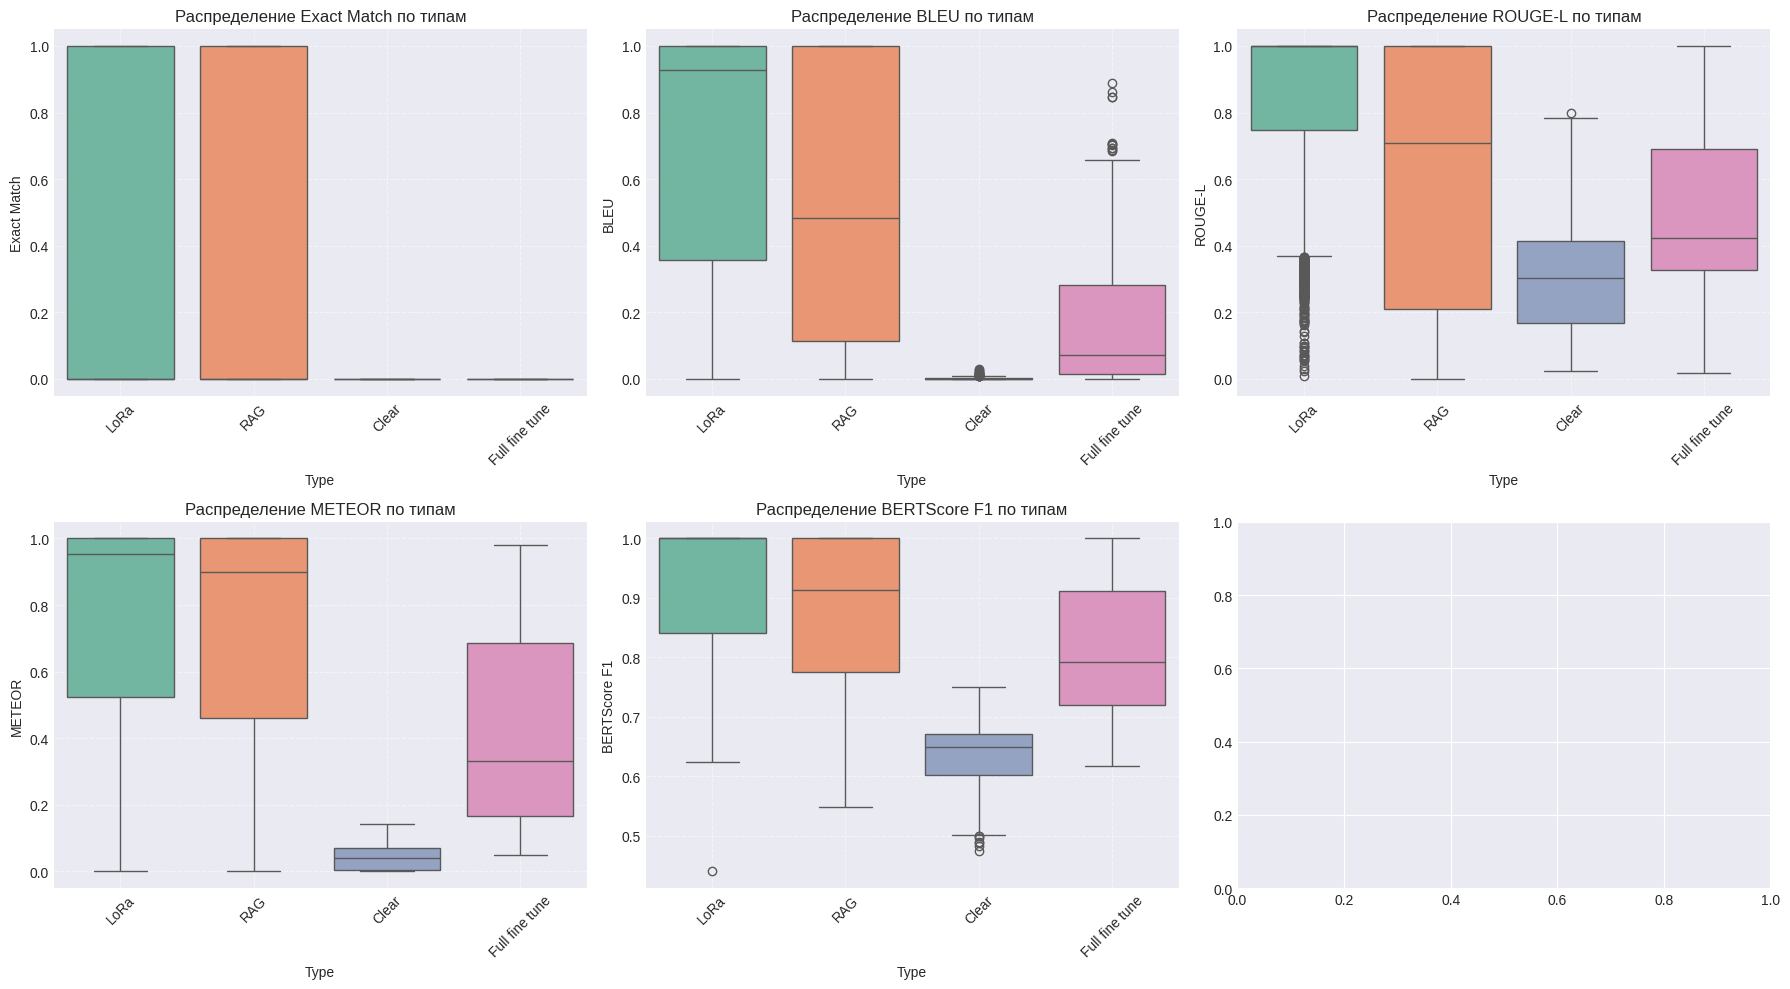

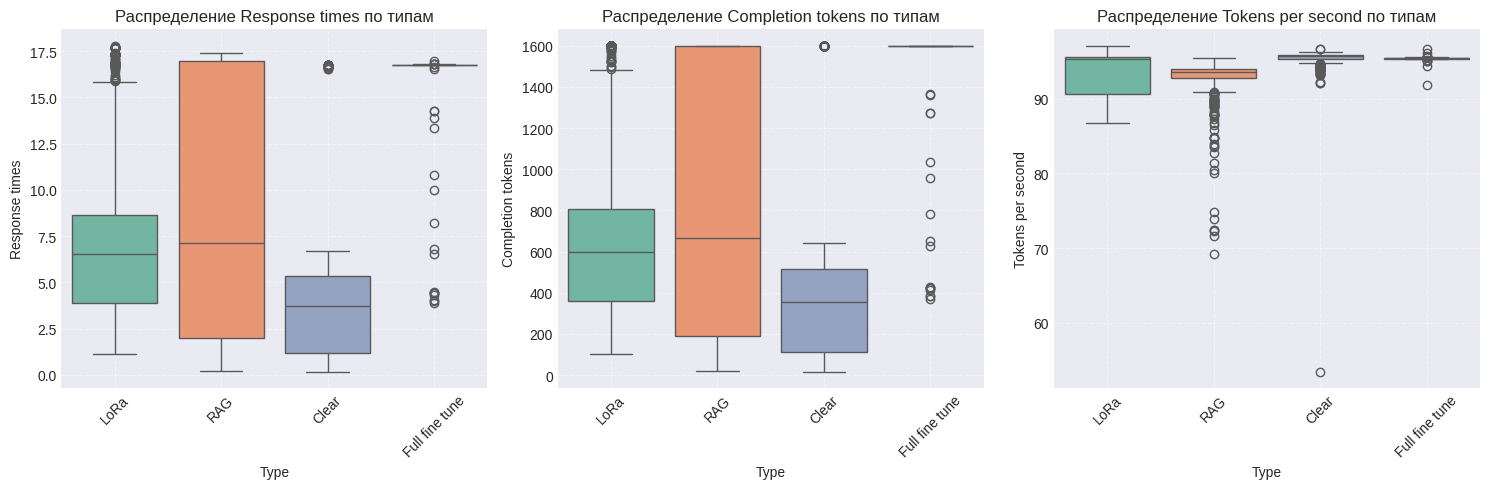

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, metric in enumerate(quality_metrics):
    sns.boxplot(data=dfs_all, x='Type', y=metric, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Распределение {metric} по типам')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
    axes[i].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(performance_metrics):
    sns.boxplot(data=dfs_all, x='Type', y=metric, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Распределение {metric} по типам')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
    axes[i].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

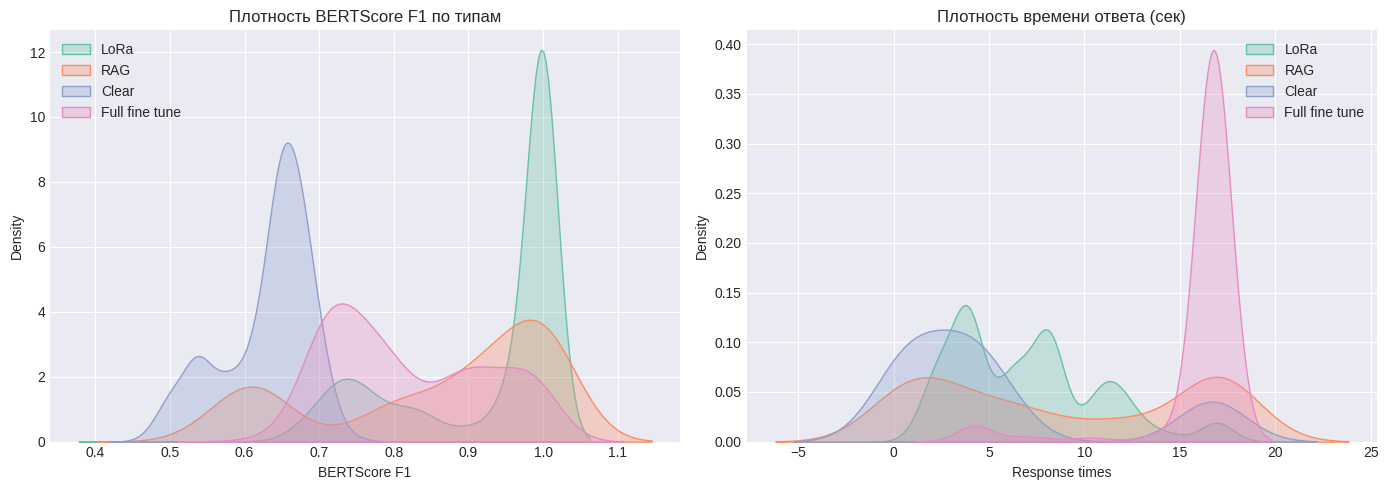

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for t in dfs_all['Type'].unique():
    subset = dfs_all[dfs_all['Type'] == t]['BERTScore F1'].dropna()
    sns.kdeplot(subset, label=t, ax=ax1, fill=True, alpha=0.3)
ax1.set_title('Плотность BERTScore F1 по типам')
ax1.legend()

for t in dfs_all['Type'].unique():
    subset = dfs_all[dfs_all['Type'] == t]['Response times'].dropna()
    sns.kdeplot(subset, label=t, ax=ax2, fill=True, alpha=0.3)
ax2.set_title('Плотность времени ответа (сек)')
ax2.legend()
plt.tight_layout()
plt.show()

In [13]:
from scipy.stats import f_oneway, kruskal

print("Проверка значимости различий между типами:")
for metric in quality_metrics + performance_metrics:
    groups = [dfs_all[dfs_all['Type'] == t][metric].dropna() for t in dfs_all['Type'].unique()]
    # Проверка нормальности (упрощённо – используем Kruskal-Wallis, если выборки не нормальны)
    try:
        h_stat, p_value = kruskal(*groups)
        print(f"{metric:20} | Kruskal-Wallis p-value = {p_value:.6f} -> {'Есть различия' if p_value < 0.05 else 'Нет различий'}")
    except:
        print(f"{metric:20} | недостаточно данных")

Проверка значимости различий между типами:
Exact Match          | Kruskal-Wallis p-value = 0.000000 -> Есть различия
BLEU                 | Kruskal-Wallis p-value = 0.000000 -> Есть различия
ROUGE-L              | Kruskal-Wallis p-value = 0.000000 -> Есть различия
METEOR               | Kruskal-Wallis p-value = 0.000000 -> Есть различия
BERTScore F1         | Kruskal-Wallis p-value = 0.000000 -> Есть различия
Response times       | Kruskal-Wallis p-value = 0.000000 -> Есть различия
Completion tokens    | Kruskal-Wallis p-value = 0.000000 -> Есть различия
Tokens per second    | Kruskal-Wallis p-value = 0.000000 -> Есть различия


In [14]:
# Нормализуем метрики качества (чем выше, тем лучше) и времени ответа (чем ниже, тем лучше)
quality_list = quality_metrics
perf_time = 'Response times'  # чем меньше, тем лучше
perf_tps = 'Tokens per second'  # чем больше, тем лучше

# Создаём копию для расчётов
df_rank = dfs_all.copy()

# Нормализация min-max по каждому столбцу
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# Качество: все шкалы "больше-лучше"
quality_normalized = scaler.fit_transform(df_rank[quality_list])
quality_score = quality_normalized.mean(axis=1)

# Производительность: время ответа инвертируем (меньше = лучше), tps оставляем как есть
time_inv = 1 / (df_rank['Response times'] + 1e-6)  # инверсия
tps_norm = scaler.fit_transform(df_rank[['Tokens per second']]).flatten()
time_norm = scaler.fit_transform(time_inv.values.reshape(-1, 1)).flatten()
perf_score = (time_norm + tps_norm) / 2

df_rank['quality_score'] = quality_score
df_rank['perf_score'] = perf_score
df_rank['total_score'] = 0.6 * quality_score + 0.4 * perf_score  # вес можно менять

# Свод по типам
ranking = df_rank.groupby('Type')[['quality_score', 'perf_score', 'total_score']].mean().sort_values('total_score', ascending=False)
print("\nИтоговый рейтинг типов (средние нормализованные оценки):")
display(ranking)


Итоговый рейтинг типов (средние нормализованные оценки):


,quality_score,perf_score,total_score
Type,,,
LoRa,0.726471,0.471489,0.624478
RAG,0.566111,0.480749,0.531966
Full fine tune,0.358943,0.481504,0.407968
Clear,0.138149,0.557711,0.305974


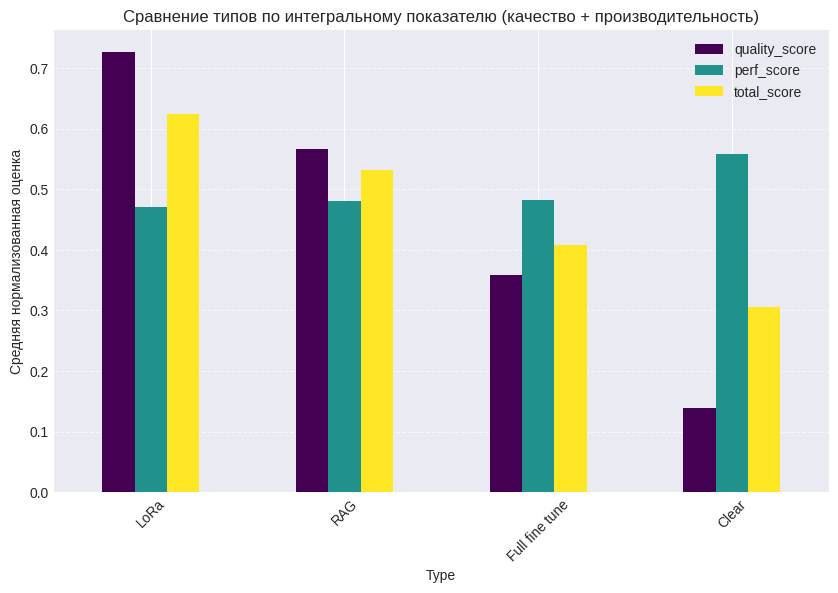

In [15]:
ranking.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Сравнение типов по интегральному показателю (качество + производительность)')
plt.ylabel('Средняя нормализованная оценка')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [16]:
best_type = ranking['total_score'].idxmax()
best_quality = ranking['quality_score'].idxmax()
best_perf = ranking['perf_score'].idxmax()

print(f"\n🏆 Лучший тип по интегральному критерию (качество 60% / скорость 40%): **{best_type}**")
print(f"📊 Лучший по качеству ответов: {best_quality}")
print(f"⚡ Лучший по производительности: {best_perf}")
print("\nРекомендация: используйте", best_type, "если ваша цель — сбалансированный результат.")


🏆 Лучший тип по интегральному критерию (качество 60% / скорость 40%): **LoRa**
📊 Лучший по качеству ответов: LoRa
⚡ Лучший по производительности: Clear

Рекомендация: используйте LoRa если ваша цель — сбалансированный результат.


In [17]:
# Метрики для анализа
quality_metrics = ['Exact Match', 'BLEU', 'ROUGE-L', 'METEOR', 'BERTScore F1']
performance_metrics = ['Response times', 'Completion tokens', 'Tokens per second']

# Группировка по Adapter name
adapter_stats = dfs_all.groupby('Adapter name')[quality_metrics + performance_metrics].agg(['mean', 'std', 'count'])
display(adapter_stats)

Exact Match            \
                                                          mean       std   
Adapter name                                                               
VLLM_TEST_RAG_meta-llama_Llama-3.1-8B-Instruct_...    0.247619  0.433699   
VLLM_TEST_RAG_ruslandev_llama-3-8b-gpt-4o-ru1.0...    0.523810  0.501828   
VLLM_TEST_RAG_ruslanmv_Medical-Llama3-8B_with_m...    0.000000  0.000000   
VLLM_TEST_with_metrics_adapter_meta-llama_Llama...    0.000000  0.000000   
VLLM_TEST_with_metrics_adapter_meta-llama_Llama...    0.676190  0.470173   
VLLM_TEST_with_metrics_adapter_meta-llama_Llama...    0.352381  0.480003   
VLLM_TEST_with_metrics_adapter_meta-llama_Llama...    0.323810  0.470173   
VLLM_TEST_with_metrics_adapter_meta-llama_Llama...    0.657143  0.476941   
VLLM_TEST_with_metrics_adapter_meta-llama_Llama...    0.638095  0.482856   
VLLM_TEST_with_metrics_adapter_meta-llama_Llama...    0.657143  0.476941   
VLLM_TEST_with_metrics_adapter_meta-llama_Llama...    0.580952  0.495770   
VLLM_TEST_with_metrics_adapter_meta-llama_Llama...    0.561905  0.498533   
VLLM_TEST_with_metrics_adapter_meta-llama_Llama...    0.038095  0.192344   
VLLM_TEST_with_metrics_adapter_meta-llama_Llama...    0.666667  0.473665   
VLLM_TEST_with_metrics_adapter_meta-llama_Llama...    0.647619  0.480003   
VLLM_TEST_with_metrics_adapter_meta-llama_Llama...    0.000000  0.000000   
VLLM_TEST_with_metrics_adapter_meta-llama_Llama...    0.676190  0.470173   
VLLM_TEST_with_metrics_adapter_meta-llama_Llama...    0.276190  0.449257   
VLLM_TEST_with_metrics_adapter_meta-llama_Llama...    0.619048  0.487950   
VLLM_TEST_with_metrics_adapter_meta-llama_Llama...    0.000000  0.000000   
VLLM_TEST_with_metrics_adapter_meta-llama_Llama...    0.009524  0.097590   
VLLM_TEST_with_metrics_adapter_meta-llama_Llama...    0.485714  0.502193   
VLLM_TEST_with_metrics_adapter_meta-llama_Llama...    0.571429  0.497245   
VLLM_TEST_with_metrics_adapter_meta-llama_Llama...    0.504762  0.502375   
VLLM_TEST_with_metrics_adapter_meta-llama_Llama...    0.000000  0.000000   
VLLM_TEST_with_metrics_adapter_meta-llama_Llama...    0.000000  0.000000   
VLLM_TEST_with_metrics_adapter_ruslandev_llama-...    0.685714  0.466457   
VLLM_TEST_with_metrics_adapter_ruslandev_llama-...    0.647619  0.480003   
VLLM_TEST_with_metrics_adapter_ruslanmv_Medical...    0.685714  0.466457   
VLLM_TEST_with_metrics_adapter_ruslanmv_Medical...    0.676190  0.470173   
VLLM_TEST_with_metrics_adapter_ruslanmv_Medical...    0.685714  0.466457   
VLLM_TEST_with_metrics_adapter_ruslanmv_Medical...    0.685714  0.466457   
VLLM_TEST_with_metrics_adapter_ruslanmv_Medical...    0.657143  0.476941   
VLLM_TEST_with_metrics_adapter_ruslanmv_Medical...    0.533333  0.501280   
VLLM_TEST_with_metrics_adapter_ruslanmv_Medical...    0.695238  0.462514   
VLLM_TEST_with_metrics_adapter_ruslanmv_Medical...    0.628571  0.485504   
VLLM_TEST_with_metrics_adapter_ruslanmv_Medical...    0.561905  0.498533   
VLLM_TEST_with_metrics_adapter_ruslanmv_Medical...    0.352381  0.480003   
VLLM_TEST_with_metrics_adapter_ruslanmv_Medical...    0.000000  0.000000   
VLLM_TEST_with_metrics_adapter_ruslanmv_Medical...    0.000000  0.000000   
VLLM_TEST_with_metrics_clear_model_meta-llama_L...    0.000000  0.000000   
VLLM_TEST_with_metrics_clear_model_meta-llama_L...    0.000000  0.000000   
VLLM_TEST_with_metrics_clear_model_meta-llama_L...    0.000000  0.000000   
VLLM_TEST_with_metrics_clear_model_ruslandev_ll...    0.000000  0.000000   
VLLM_TEST_with_metrics_clear_model_ruslanmv_Med...    0.000000  0.000000   

                                                              BLEU            \
                                                   count      mean       std   
Adapter name                                                                   
VLLM_TEST_RAG_meta-llama_Llama-3.1-8B-Instruct_...   105  0.378796  0.477502   
VLLM_TEST_RAG_ruslandev_llama-3-8b-gpt-4o-ru1.0...   105  0.848234  0.315187   
VL

In [18]:
percentiles = [0.1, 0.25, 0.5, 0.75, 0.9]
for metric in quality_metrics + performance_metrics:
    print(f"\nПроцентили для {metric} по адаптерам:")
    perc_df = dfs_all.groupby('Adapter name')[metric].quantile(percentiles).unstack()
    display(perc_df.head())  # покажем первые несколько, чтобы не загромождать


Процентили для Exact Match по адаптерам:


,0.10,0.25,0.50,0.75,0.90
Adapter name,,,,,
VLLM_TEST_RAG_meta-llama_Llama-3.1-8B-Instruct_with_metrics,0.0,0.0,0.0,0.0,1.0
VLLM_TEST_RAG_ruslandev_llama-3-8b-gpt-4o-ru1.0_with_metrics,0.0,0.0,1.0,1.0,1.0
VLLM_TEST_RAG_ruslanmv_Medical-Llama3-8B_with_metrics,0.0,0.0,0.0,0.0,0.0
VLLM_TEST_with_metrics_adapter_meta-llama_Llama-3.1-8B-Instruct_lora_epochs_10_batch_2_optim_adamw_torch_fused_r_16_alpha32,0.0,0.0,0.0,0.0,0.0
VLLM_TEST_with_metrics_adapter_meta-llama_Llama-3.1-8B-Instruct_lora_epochs_10_batch_2_optim_adamw_torch_fused_r_16_alpha_32_q_proj_v_proj_k_proj_o_proj_gate_proj_up_proj_down_proj_embed_tokens_lm_head,0.0,0.0,1.0,1.0,1.0



Процентили для BLEU по адаптерам:


,0.10,0.25,0.50,0.75,0.90
Adapter name,,,,,
VLLM_TEST_RAG_meta-llama_Llama-3.1-8B-Instruct_with_metrics,0.000000,0.000025,0.000380,0.994723,1.000000
VLLM_TEST_RAG_ruslandev_llama-3-8b-gpt-4o-ru1.0_with_metrics,0.304892,0.964235,1.000000,1.000000,1.000000
VLLM_TEST_RAG_ruslanmv_Medical-Llama3-8B_with_metrics,0.119522,0.216828,0.381865,0.482461,0.717018
VLLM_TEST_with_metrics_adapter_meta-llama_Llama-3.1-8B-Instruct_lora_epochs_10_batch_2_optim_adamw_torch_fused_r_16_alpha32,0.001645,0.029535,0.134369,0.672293,0.873746
VLLM_TEST_with_metrics_adapter_meta-llama_Llama-3.1-8B-Instruct_lora_epochs_10_batch_2_optim_adamw_torch_fused_r_16_alpha_32_q_proj_v_proj_k_proj_o_proj_gate_proj_up_proj_down_proj_embed_tokens_lm_head,0.754423,0.890254,1.000000,1.000000,1.000000



Процентили для ROUGE-L по адаптерам:


...

,0.10,0.25,0.50,0.75,0.90
Adapter name,,,,,
VLLM_TEST_RAG_meta-llama_Llama-3.1-8B-Instruct_with_metrics,0.589652,0.682223,1.012029,6.262366,11.981847
VLLM_TEST_RAG_ruslandev_llama-3-8b-gpt-4o-ru1.0_with_metrics,1.859201,2.838055,5.279455,8.041866,12.182658
VLLM_TEST_RAG_ruslanmv_Medical-Llama3-8B_with_metrics,16.937130,16.969117,17.026992,17.076930,17.137606
VLLM_TEST_with_metrics_adapter_meta-llama_Llama-3.1-8B-Instruct_lora_epochs_10_batch_2_optim_adamw_torch_fused_r_16_alpha32,3.397184,4.061222,7.499655,12.625969,17.673631
VLLM_TEST_with_metrics_adapter_meta-llama_Llama-3.1-8B-Instruct_lora_epochs_10_batch_2_optim_adamw_torch_fused_r_16_alpha_32_q_proj_v_proj_k_proj_o_proj_gate_proj_up_proj_down_proj_embed_tokens_lm_head,2.422723,3.879996,6.503011,8.537437,12.107058



Процентили для Completion tokens по адаптерам:


,0.10,0.25,0.50,0.75,0.90
Adapter name,,,,,
VLLM_TEST_RAG_meta-llama_Llama-3.1-8B-Instruct_with_metrics,51.8,62.0,89.0,587.0,1118.0
VLLM_TEST_RAG_ruslandev_llama-3-8b-gpt-4o-ru1.0_with_metrics,174.4,267.0,493.0,751.0,1135.0
VLLM_TEST_RAG_ruslanmv_Medical-Llama3-8B_with_metrics,1600.0,1600.0,1600.0,1600.0,1600.0
VLLM_TEST_with_metrics_adapter_meta-llama_Llama-3.1-8B-Instruct_lora_epochs_10_batch_2_optim_adamw_torch_fused_r_16_alpha32,307.8,368.0,679.0,1144.0,1600.0
VLLM_TEST_with_metrics_adapter_meta-llama_Llama-3.1-8B-Instruct_lora_epochs_10_batch_2_optim_adamw_torch_fused_r_16_alpha_32_q_proj_v_proj_k_proj_o_proj_gate_proj_up_proj_down_proj_embed_tokens_lm_head,219.6,351.0,589.0,772.0,1097.0



Процентили для Tokens per second по адаптерам:


,0.10,0.25,0.50,0.75,0.90
Adapter name,,,,,
VLLM_TEST_RAG_meta-llama_Llama-3.1-8B-Instruct_with_metrics,84.870156,89.080119,90.867837,93.653696,94.070033
VLLM_TEST_RAG_ruslandev_llama-3-8b-gpt-4o-ru1.0_with_metrics,92.278351,93.240028,93.555638,93.888550,94.071269
VLLM_TEST_RAG_ruslanmv_Medical-Llama3-8B_with_metrics,93.361932,93.693658,93.968446,94.288937,94.467006
VLLM_TEST_with_metrics_adapter_meta-llama_Llama-3.1-8B-Instruct_lora_epochs_10_batch_2_optim_adamw_torch_fused_r_16_alpha32,90.462691,90.561098,90.620065,90.708696,90.869056
VLLM_TEST_with_metrics_adapter_meta-llama_Llama-3.1-8B-Instruct_lora_epochs_10_batch_2_optim_adamw_torch_fused_r_16_alpha_32_q_proj_v_proj_k_proj_o_proj_gate_proj_up_proj_down_proj_embed_tokens_lm_head,90.397497,90.441615,90.506724,90.582678,90.683354


In [19]:
def mean_ci(data, confidence=0.95):
    n = len(data)
    mean = np.mean(data)
    se = stats.sem(data)
    h = se * stats.t.ppf((1 + confidence) / 2., n-1)
    return mean - h, mean + h

ci_data = []
for adapter in dfs_all['Adapter name'].unique():
    row = {'Adapter name': adapter}
    for metric in quality_metrics + performance_metrics:
        values = dfs_all[dfs_all['Adapter name'] == adapter][metric].dropna()
        if len(values) > 1:
            low, high = mean_ci(values)
            row[f'{metric}_ci_low'] = low
            row[f'{metric}_ci_high'] = high
    ci_data.append(row)

ci_df = pd.DataFrame(ci_data)
display(ci_df)

,Adapter name,Exact Match_ci_low,Exact Match_ci_high,BLEU_ci_low,BLEU_ci_high,ROUGE-L_ci_low,ROUGE-L_ci_high,METEOR_ci_low,METEOR_ci_high,BERTScore F1_ci_low,BERTScore F1_ci_high,Response times_ci_low,Response times_ci_high,Completion tokens_ci_low,Completion tokens_ci_high,Tokens per second_ci_low,Tokens per second_ci_high
0,VLLM_TEST_with_metrics_adapter_ruslanmv_Medica...,0.585200,0.767180,0.857127,0.939355,0.944673,0.986160,0.885570,0.951920,0.973748,0.992303,6.057197,7.426441,548.528803,672.461673,90.530358,90.586546
1,VLLM_TEST_with_metrics_adapter_ruslanmv_Medica...,0.000000,0.000000,0.247199,0.383116,0.566515,0.652456,0.402765,0.521568,0.802992,0.840099,8.181610,10.069501,781.408973,961.429122,95.505196,95.549464
2,VLLM_TEST_with_metrics_adapter_meta-llama_Llam...,0.232820,0.414800,0.671080,0.805195,0.819153,0.903949,0.745175,0.851639,0.919179,0.955337,6.287177,7.792915,570.403565,706.891673,90.703995,90.753358
3,VLLM_TEST_with_metrics_adapter_ruslanmv_Medica...,0.259489,0.445273,0.828571,0.913843,0.942585,0.980941,0.869678,0.936466,0.966154,0.986627,6.058170,7.352242,549.020923,666.217172,90.599955,90.650357
4,VLLM_TEST_with_metrics_adapter_ruslanmv_Medica...,0.000000,0.000000,0.126700,0.206042,0.447167,0.530627,0.284169,0.364273,0.758707,0.787559,8.037179,9.839959,767.699461,939.576730,95.508852,95.566664
5,VLLM_TEST_with_metrics_adapter_meta-llama_Llam...,0.524617,0.713478,0.836631,0.929047,0.927810,0.981128,0.870028,0.945441,0.967263,0.990803,6.279029,7.753534,568.364730,701.692413,90.489496,90.552894
6,VLLM_TEST_with_metrics_adapter_meta-llama_Llam...,0.259489,0.445273,0.554778,0.717656,0.743781,0.854812,0.643731,0.777471,0.883595,0.927546,6.937561,8.824591,641.672123,815.985020,92.436888,92.546245
7,VLLM_TEST_with_metrics_adapter_ruslandev_llama...,0.554727,0.740511,0.870309,0.947781,0.951379,0.989409,0.891929,0.956647,0.975704,0.993905,5.981610,7.314416,542.144321,662.865203,90.578628,90.671163
8,VLLM_TEST_with_metrics_adapter_meta-llama_Llam...,0.189248,0.363133,0.497530,0.653600,0.730399,0.827248,0.596487,0.725870,0.873727,0.917120,6.464069,8.016092,617.335328,765.350387,95.483870,95.534295
9,VLLM_TEST_with_metrics_adapter_meta-llama_Llam...,0.407540,0.601984,0.849123,0.928793,0.946695,0.986810,0.883084,0.946315,0.969561,0.990355,5.996618,7.283921,544.497969,661.292507,90.777306,90.830092


In [20]:
# Сначала посчитаем средние значения для каждого адаптера
adapter_mean = dfs_all.groupby('Adapter name')[quality_metrics + performance_metrics].mean().reset_index()

# Нормализация качества (все метрики "больше-лучше")
scaler = MinMaxScaler()
quality_normalized = scaler.fit_transform(adapter_mean[quality_metrics])
adapter_mean['quality_score'] = quality_normalized.mean(axis=1)

# Нормализация производительности: Response times (меньше-лучше) инвертируем, Tokens per second (больше-лучше)
time_inv = 1 / (adapter_mean['Response times'] + 1e-6)
tps_norm = scaler.fit_transform(adapter_mean[['Tokens per second']]).flatten()
time_norm = scaler.fit_transform(time_inv.values.reshape(-1, 1)).flatten()
adapter_mean['perf_score'] = (time_norm + tps_norm) / 2

# Интегральный score (вес качества 0.6, производительности 0.4 – можно менять)
adapter_mean['total_score'] = 0.6 * adapter_mean['quality_score'] + 0.4 * adapter_mean['perf_score']

# Сортировка адаптеров по total_score
ranking_adapters = adapter_mean.sort_values('total_score', ascending=False).reset_index(drop=True)
print("🏆 Рейтинг адаптеров (от лучшего к худшему):")
display(ranking_adapters[['Adapter name', 'quality_score', 'perf_score', 'total_score']])

🏆 Рейтинг адаптеров (от лучшего к худшему):


,Adapter name,quality_score,perf_score,total_score
0,VLLM_TEST_with_metrics_adapter_meta-llama_Llam...,0.985543,0.677562,0.862351
1,VLLM_TEST_with_metrics_adapter_meta-llama_Llam...,0.982006,0.681274,0.861713
2,VLLM_TEST_with_metrics_adapter_meta-llama_Llam...,0.978081,0.676638,0.857504
3,VLLM_TEST_with_metrics_adapter_meta-llama_Llam...,0.985901,0.663481,0.856933
4,VLLM_TEST_with_metrics_adapter_ruslanmv_Medica...,0.987326,0.660759,0.856699
5,VLLM_TEST_with_metrics_adapter_meta-llama_Llam...,0.977528,0.667290,0.853432
6,VLLM_TEST_with_metrics_adapter_ruslanmv_Medica...,0.990912,0.643941,0.852124
7,VLLM_TEST_with_metrics_adapter_meta-llama_Llam...,0.963120,0.659548,0.841691
8,VLLM_TEST_with_metrics_adapter_meta-llama_Llam...,0.956763,0.647365,0.833004
9,VLLM_TEST_with_metrics_adapter_meta-llama_Llam...,0.941945,0.663098,0.830406


In [21]:
best_adapter = ranking_adapters.iloc[0]['Adapter name']
best_quality_adapter = ranking_adapters.loc[ranking_adapters['quality_score'].idxmax(), 'Adapter name']
best_perf_adapter = ranking_adapters.loc[ranking_adapters['perf_score'].idxmax(), 'Adapter name']

print(f"\n✅ Лучший адаптер по интегральному критерию (качество 60% / скорость 40%): **{best_adapter}**")
print(f"📊 Лучший по качеству ответов: {best_quality_adapter}")
print(f"⚡ Лучший по производительности: {best_perf_adapter}")


✅ Лучший адаптер по интегральному критерию (качество 60% / скорость 40%): **VLLM_TEST_with_metrics_adapter_meta-llama_Llama-3.1-8B-Instruct_lora_epochs_10_batch_4_optim_ademamix_r_64_alpha_128_lr_0.0002_drop_out_0.05_q_proj_v_proj_k_proj_o_proj_gate_proj_up_proj_down_proj_embed_tokens_lm_head**
📊 Лучший по качеству ответов: VLLM_TEST_with_metrics_adapter_ruslanmv_Medical-Llama3-8B_lora_epochs_10_batch_2_optim_adamw_torch_fused_r_16_alpha_32_q_proj_v_proj_k_proj_o_proj_gate_proj_up_proj_down_proj_embed_tokens_lm_head
⚡ Лучший по производительности: VLLM_TEST_with_metrics_clear_model_meta-llama_Llama-3.1-8B-Instruct


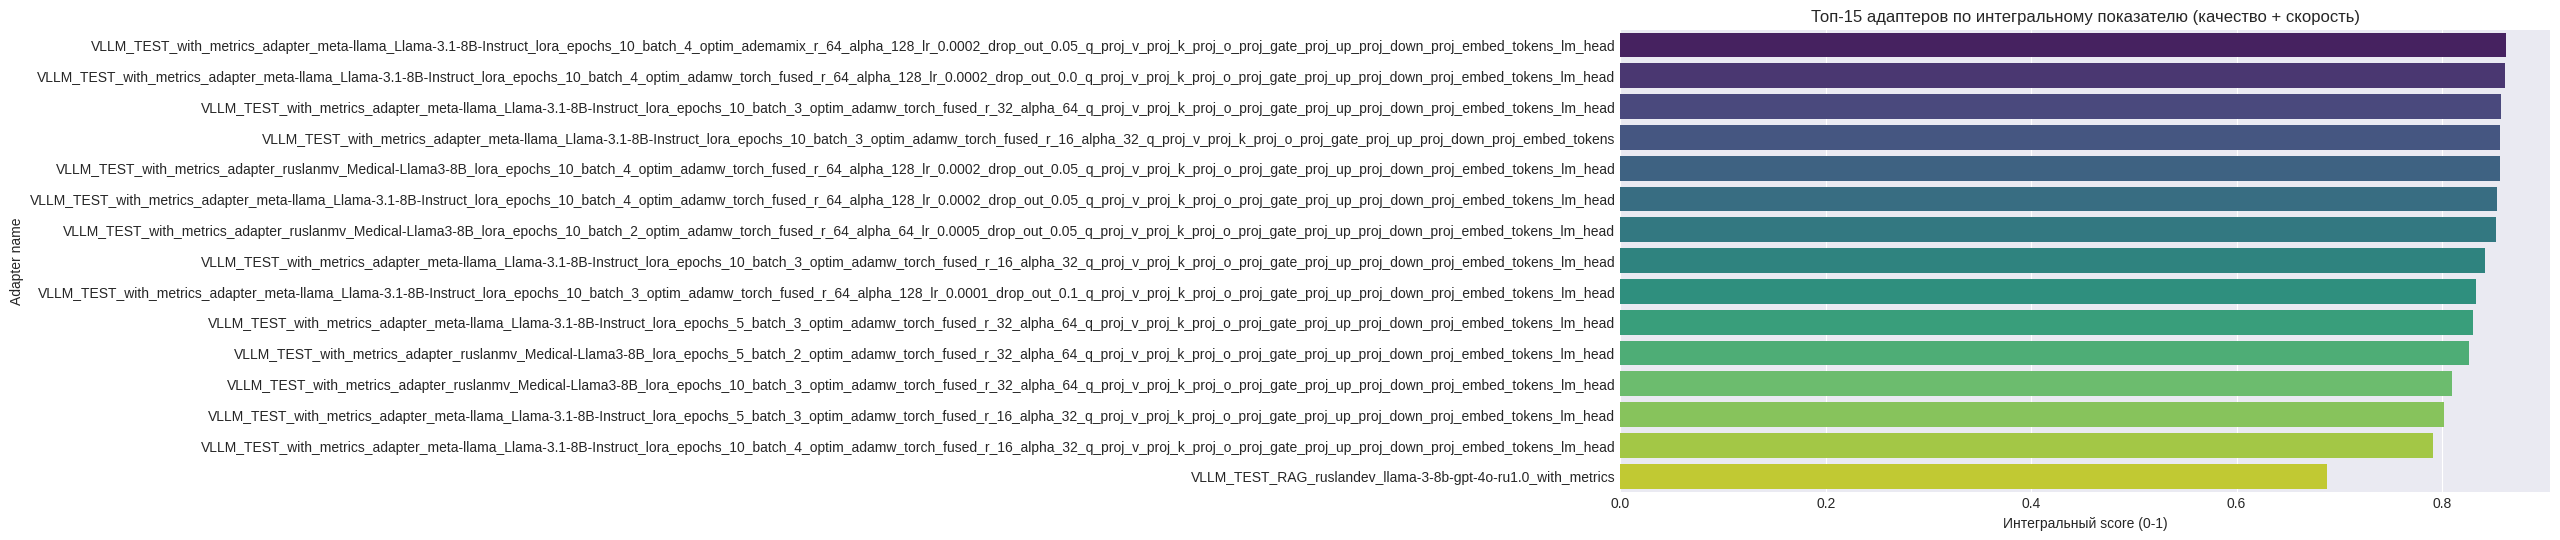

In [22]:
top_n = 15
top_adapters = ranking_adapters.head(top_n)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_adapters, x='total_score', y='Adapter name', palette='viridis')
plt.title(f'Топ-{top_n} адаптеров по интегральному показателю (качество + скорость)')
plt.xlabel('Интегральный score (0-1)')
plt.tight_layout()
plt.show()

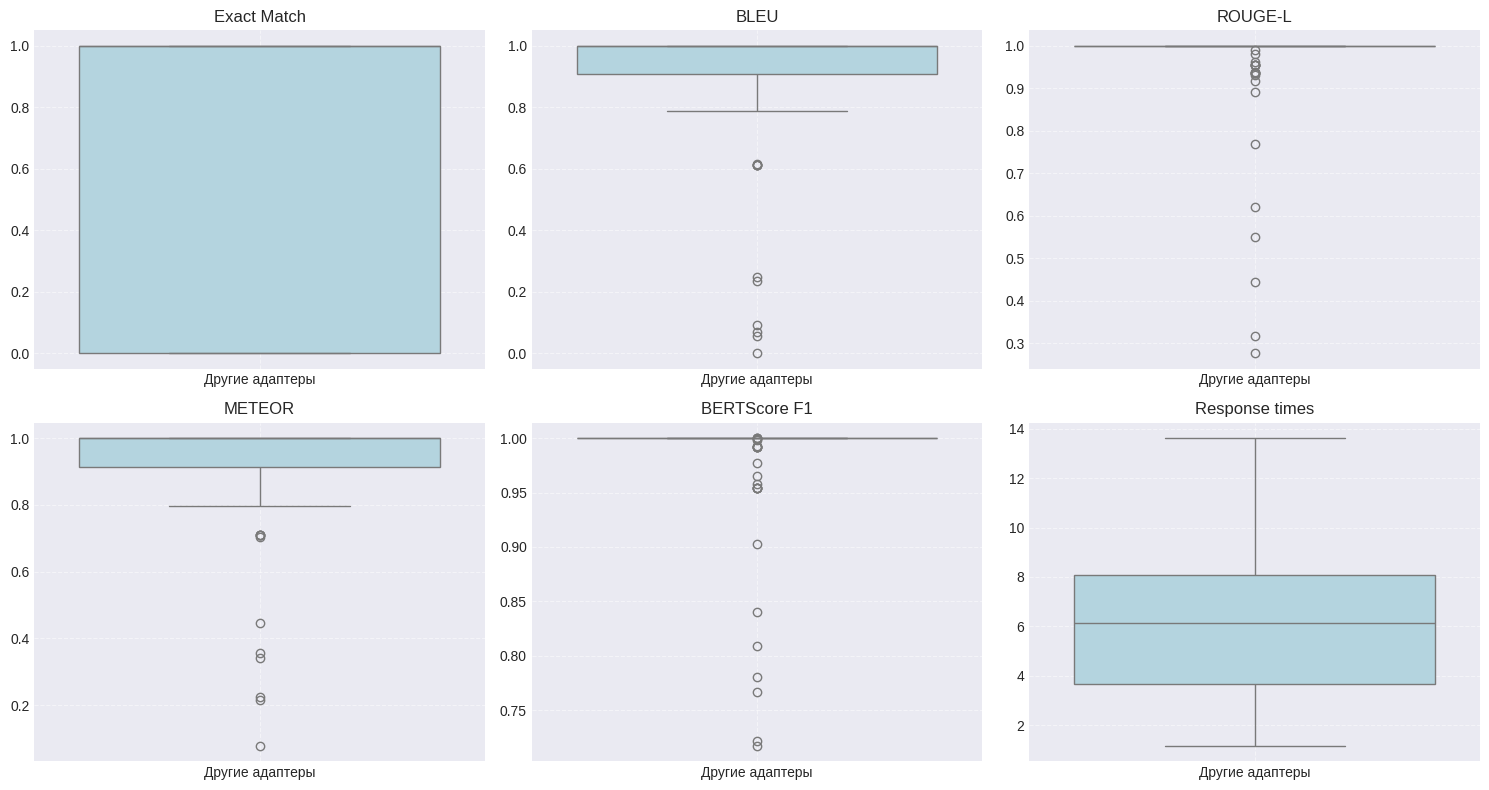

In [23]:
best_data = dfs_all[dfs_all['Adapter name'] == best_adapter]
others_data = dfs_all[dfs_all['Adapter name'] != best_adapter]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, metric in enumerate(quality_metrics + performance_metrics[:1]):  # добавим ещё время ответа
    sns.boxplot(data=[others_data[metric].dropna(), best_data[metric].dropna()], 
                ax=axes[i], palette=['lightblue', 'orange'])
    axes[i].set_xticklabels(['Другие адаптеры', best_adapter])
    axes[i].set_title(metric)
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [24]:
best_bert = best_data['BERTScore F1'].dropna()
others_bert = others_data['BERTScore F1'].dropna()

best_ci = mean_ci(best_bert)
others_ci = mean_ci(others_bert)

print(f"Доверительный интервал для BERTScore F1 у лучшего адаптера ({best_adapter}): [{best_ci[0]:.4f}, {best_ci[1]:.4f}]")
print(f"Доверительный интервал для BERTScore F1 у остальных адаптеров: [{others_ci[0]:.4f}, {others_ci[1]:.4f}]")

Доверительный интервал для BERTScore F1 у лучшего адаптера (VLLM_TEST_with_metrics_adapter_meta-llama_Llama-3.1-8B-Instruct_lora_epochs_10_batch_4_optim_ademamix_r_64_alpha_128_lr_0.0002_drop_out_0.05_q_proj_v_proj_k_proj_o_proj_gate_proj_up_proj_down_proj_embed_tokens_lm_head): [0.9719, 0.9931]
Доверительный интервал для BERTScore F1 у остальных адаптеров: [0.8929, 0.9006]


In [25]:
# Лучший адаптер по качеству ответов
best_quality_adapter = ranking_adapters.loc[ranking_adapters['quality_score'].idxmax(), 'Adapter name']
print(f"Лучший по качеству ответов: {best_quality_adapter}")

Лучший по качеству ответов: VLLM_TEST_with_metrics_adapter_ruslanmv_Medical-Llama3-8B_lora_epochs_10_batch_2_optim_adamw_torch_fused_r_16_alpha_32_q_proj_v_proj_k_proj_o_proj_gate_proj_up_proj_down_proj_embed_tokens_lm_head


In [26]:
# Лучший адаптер по качеству ответов
best_quality_adapter = ranking_adapters.loc[ranking_adapters['quality_score'].idxmax(), 'Adapter name']
best_quality_score = ranking_adapters.loc[ranking_adapters['quality_score'].idxmax(), 'quality_score']

print(f"🏆 Лучший по качеству ответов:")
print(f"   Адаптер: {best_quality_adapter}")
print(f"   Качество (quality_score): {best_quality_score:.4f}")

# Дополнительно: выведем средние значения метрик для этого адаптера
best_adapter_metrics = adapter_mean[adapter_mean['Adapter name'] == best_quality_adapter]
print("\n📊 Средние метрики качества для этого адаптера:")
for metric in quality_metrics:
    print(f"   {metric}: {best_adapter_metrics[metric].values[0]:.4f}")
    

🏆 Лучший по качеству ответов:
   Адаптер: VLLM_TEST_with_metrics_adapter_ruslanmv_Medical-Llama3-8B_lora_epochs_10_batch_2_optim_adamw_torch_fused_r_16_alpha_32_q_proj_v_proj_k_proj_o_proj_gate_proj_up_proj_down_proj_embed_tokens_lm_head
   Качество (quality_score): 0.9949

📊 Средние метрики качества для этого адаптера:
   Exact Match: 0.6857
   BLEU: 0.9139
   ROUGE-L: 0.9679
   METEOR: 0.9294
   BERTScore F1: 0.9870
